<a href="https://colab.research.google.com/github/Saiakashaya/DATA_SCIENCE/blob/main/linear_regression_for_mini_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kaggle

In [2]:
!kaggle datasets download fvcoppen/solarpanelspower

Dataset URL: https://www.kaggle.com/datasets/fvcoppen/solarpanelspower
License(s): copyright-authors
100% 67.1k/67.1k [00:00<00:00, 52.8MB/s]



In [3]:
ls-ltr /content

total 72
-rw-r--r-- 1 root root 68667 Feb 27  2022 solarpanelspower.zip
drwxr-xr-x 1 root root  4096 Jun  4 13:32 sample_data/


In [4]:
!unzip solarpanelspower.zip

Archive:  solarpanelspower.zip
  inflating: PV_Elec_Gas3.csv        
  inflating: metingen_27feb2022.csv  
  inflating: metingen_4sept2021.cvs  


In [5]:
!chmod 777 PV_Elec_Gas3.csv

In [6]:
import pandas as pd
df=pd.read_csv("PV_Elec_Gas3.csv")
df.head()

,date,Cumulative_solar_power,kWh electricity/day,Gas/day
0,26/10/2011,0.1,15.1,9.0
1,27/10/2011,10.2,7.4,9.2
2,28/10/2011,20.2,5.8,8.0
3,29/10/2011,29.6,4.9,6.6
4,30/10/2011,34.2,11.7,5.3


In [7]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/1v9cC2snQosjVN9F6KE5h-O-WvZPWgInOsrykjl-lbrk/edit#gid=0


In [8]:
print("\nMissing Values")
print(df.isnull().sum())


Missing Values
date                      0
Cumulative_solar_power    0
kWh electricity/day       0
Gas/day                   0
dtype: int64


In [9]:
df.drop_duplicates(inplace=True)
print("\nDataset Shape :", df.shape)


Dataset Shape : (3304, 4)


In [10]:
print(df.columns)

Index(['date', 'Cumulative_solar_power', 'kWh electricity/day', 'Gas/day'], dtype='object')


                        Cumulative_solar_power  kWh electricity/day   Gas/day
Cumulative_solar_power                1.000000            -0.052776 -0.137850
kWh electricity/day                  -0.052776             1.000000  0.723801
Gas/day                              -0.137850             0.723801  1.000000


In [29]:
X = df['Cumulative_solar_power']
Y= df['kWh electricity/day']

In [30]:
print(X)
Y

0           0.1
1          10.2
2          20.2
3          29.6
4          34.2
         ...   
3299    36445.0
3300    36453.0
3301    36461.0
3302    36466.0
3303    36469.0
Name: Cumulative_solar_power, Length: 3304, dtype: float64


,kWh electricity/day
0,15.1
1,7.4
2,5.8
3,4.9
4,11.7
...,...
3299,16.0
3300,13.0
3301,12.0
3302,14.0


In [32]:
import numpy as np
x=np.array(X).reshape(-1,1)
y=np.array(Y).reshape(-1,1)

In [36]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.30,
    random_state=32
)

In [37]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [38]:
y_pred = model.predict(x_test)

In [39]:
from sklearn.metrics import r2_score
r2=r2_score(y_test,y_pred)
print("\nR2 Score:",round(r2,3))


R2 Score: 0.004


In [44]:
solar_power=float(input("\nEnter cumulative solar power:"))
user=pd.DataFrame([[solar_power]],columns=["Cumulative_solar_power"])
predicted_electricity=model.predict(user)
print("\nPredicted electricity per day: ",predicted_electricity)


Enter cumulative solar power:89

Predicted electricity per day:  [[5.19000968]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


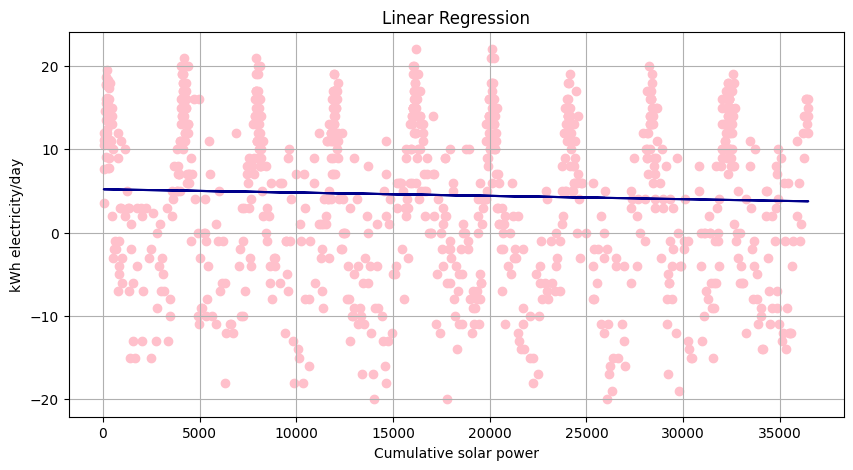

In [51]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.scatter(x_test,y_test,color="pink")
plt.plot(x_test,y_pred,color="darkblue")
plt.title("Linear Regression")
plt.xlabel("Cumulative solar power")
plt.ylabel("kWh electricity/day")
plt.grid(True)
plt.show()